In [ ]:
import sys
import os
from pathlib import Path

import torch

sys.path.append(os.path.abspath("../src"))

from models import EfficientNetB0

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())
df["Finding Labels"].value_counts().head()

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
Total images: 112120
Unique patients: 30805


Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [ ]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [4]:
train_loader, val_loader, test_loader = prepare_data(df)

device = get_device()

model = EfficientNetB0(num_classes=2, in_channels=1).to(device)

criterion, optimizer = setup_training(model)

Using MPS (GPU)


In [5]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "efficientnetb0_binary_target", 3)

Val Epoch 1:   0%|          | 0/1055 [00:00<?, ?it/s]python(46025) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46033) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46034) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46042) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46043) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46051) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46052) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46061) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46069) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46070) MallocStackLogging: can't turn off malloc stack log

Epoch 1/10 | ETA (Remaining): 05:10:32 | Total ETA: 05:45:03
  Train Loss: 0.6658 | Train Acc: 0.6026
  Val Loss: 0.6434 | Val Acc: 0.6517
  Val Precision: 0.6408
  Val Recall: 0.5376 | Val F1: 0.5847
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/efficientnetb0_binary_target.pt
------------------------------------------------------------


Train Epoch 2:   0%|          | 0/4934 [00:00<?, ?it/s]python(47031) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47044) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47052) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47053) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47061) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47069) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47070) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47078) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47079) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(47087) MallocStackLogging: can't turn off malloc stack l

Epoch 2/10 | ETA (Remaining): 04:13:25 | Total ETA: 05:45:03
  Train Loss: 0.6361 | Train Acc: 0.6498
  Val Loss: 0.6196 | Val Acc: 0.6669
  Val Precision: 0.6309
  Val Recall: 0.6499 | Val F1: 0.6403
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/efficientnetb0_binary_target.pt
------------------------------------------------------------


Train Epoch 3:   0%|          | 0/4934 [00:00<?, ?it/s]python(53186) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53198) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53206) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53207) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53216) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53217) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53225) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53233) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53234) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(53242) MallocStackLogging: can't turn off malloc stack l

...

Epoch 7/10 | ETA (Remaining): 01:24:34 | Total ETA: 05:45:03
  Train Loss: 0.5918 | Train Acc: 0.6962
  Val Loss: 0.5998 | Val Acc: 0.6885
  Val Precision: 0.6750
  Val Recall: 0.6114 | Val F1: 0.6416
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Train Epoch 8:   0%|          | 0/4934 [00:00<?, ?it/s]python(82205) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82213) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82221) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82222) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82230) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82231) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82239) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82247) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82248) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(82256) MallocStackLogging: can't turn off malloc stack l

Epoch 8/10 | ETA (Remaining): 00:55:42 | Total ETA: 05:45:03
  Train Loss: 0.5859 | Train Acc: 0.7023
  Val Loss: 0.6006 | Val Acc: 0.6912
  Val Precision: 0.6621
  Val Recall: 0.6593 | Val F1: 0.6607
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Train Epoch 9:   0%|          | 0/4934 [00:00<?, ?it/s]python(87741) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87749) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87750) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87758) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87759) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87767) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87775) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87776) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87784) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(87785) MallocStackLogging: can't turn off malloc stack l

Epoch 9/10 | ETA (Remaining): 00:27:58 | Total ETA: 05:45:03
  Train Loss: 0.5802 | Train Acc: 0.7053
  Val Loss: 0.6018 | Val Acc: 0.6908
  Val Precision: 0.6534
  Val Recall: 0.6858 | Val F1: 0.6692
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 9 (patience 3 exceeded)


(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

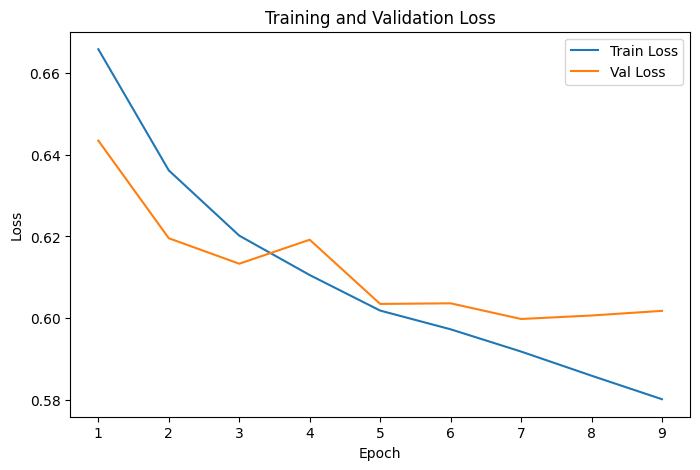

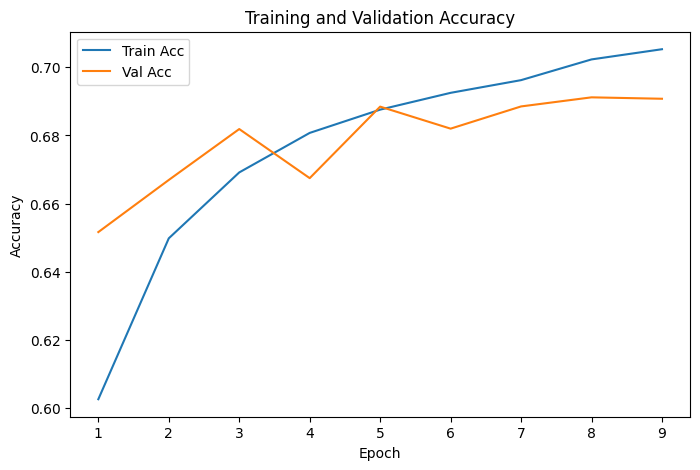

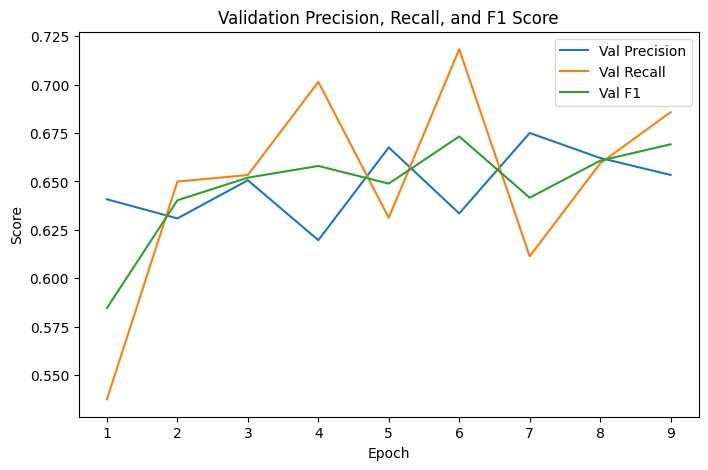

In [6]:
plot_training_history(history)

In [7]:
save_path = get_model_path("efficientnetb0_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = EfficientNetB0(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/efficientnetb0_binary_target.pt


Val:   0%|          | 0/1020 [00:00<?, ?it/s]python(94499) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94507) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94516) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94521) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94531) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94540) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94541) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94550) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94551) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94559) MallocStackLogging: can't turn off malloc stack logging bec

Test Results
  Loss: 0.6013
  Accuracy: 0.6843
  Precision: 0.6390
  Recall: 0.7279
  F1 Score: 0.6806


In [ ]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"])
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])

Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_005/images/00010365_001.png
Predicted class: normal
True label: normal
Probabilities: {'normal': 0.7901871204376221, 'abnormal': 0.2098129242658615}
